In order to test the validity of PIGLASSO we use the benchmark sets as available from the DREAM5 challange. Weuse the 4 available datasets (including 4 different networks).

Before feeding the benchmark sets to PIGLASSO, we first need to ensure correct formatting and scaling. This is done below. The formatting and scaling is done in the same manner as done for the burn data.


In [5]:
from pathlib import Path
import numpy as np
import pandas as pd

# ----------------------------
# CONFIG
# ----------------------------
BENCH_ROOT = Path("/Users/zoeazra/Documents/CLS/Y2/Thesis/Implementation/BurnInjuries/benchmark_data")
OUT_DIR = BENCH_ROOT / "preprocessed"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RECURSIVE = False
DO_ZSCORE = True

# ----------------------------
# Helpers
# ----------------------------
def zscore_rows(X: pd.DataFrame) -> pd.DataFrame:
    mu = X.mean(axis=1)
    sd = X.std(axis=1, ddof=1).replace(0, np.nan)
    Z = X.sub(mu, axis=0).div(sd, axis=0)
    return Z.dropna(axis=0)

def preprocess_dream5_tsv(in_tsv: Path, out_tsv: Path, do_zscore: bool = True):
    # DREAM5 format: rows = samples, columns = genes
    df = pd.read_csv(in_tsv, sep="\t")

    # Ensure numeric
    X = df.apply(pd.to_numeric, errors="coerce")

    # Check orientation
    print(f"   Raw shape (samples x genes): {X.shape}")

    # Transpose to genes x samples
    X = X.T

    print(f"   Transposed (genes x samples): {X.shape}")

    if do_zscore:
        X = zscore_rows(X)

    out_tsv.parent.mkdir(parents=True, exist_ok=True)
    X.to_csv(out_tsv, sep="\t")

    return X.shape

# ----------------------------
# Find DREAM5 files
# ----------------------------
pattern = "*.tsv" if not RECURSIVE else "**/*.tsv"
files = sorted(BENCH_ROOT.glob(pattern))

if not files:
    raise FileNotFoundError(f"No .tsv files found in {BENCH_ROOT.resolve()}")

print(f"[INFO] Found {len(files)} DREAM5 expression files.")
for f in files:
    print("  -", f.name)

# ----------------------------
# Process all
# ----------------------------
summary = []

for i, fp in enumerate(files, start=1):
    print(f"\n[{i}/{len(files)}] Processing: {fp.name}")

    out_fp = OUT_DIR / fp.name

    shape = preprocess_dream5_tsv(fp, out_fp, do_zscore=DO_ZSCORE)

    print(f"   -> wrote {out_fp.name}  shape={shape}")

    summary.append({
        "input": fp.name,
        "output": out_fp.name,
        "genes": shape[0],
        "samples": shape[1]
    })

summary_df = pd.DataFrame(summary)
display(summary_df)

[INFO] Found 4 DREAM5 expression files.
  - net1_expression_data.tsv
  - net2_expression_data.tsv
  - net3_expression_data.tsv
  - net4_expression_data.tsv

[1/4] Processing: net1_expression_data.tsv
   Raw shape (samples x genes): (805, 1643)
   Transposed (genes x samples): (1643, 805)
   -> wrote net1_expression_data.tsv  shape=(1643, 805)

[2/4] Processing: net2_expression_data.tsv
   Raw shape (samples x genes): (160, 2810)
   Transposed (genes x samples): (2810, 160)
   -> wrote net2_expression_data.tsv  shape=(2810, 160)

[3/4] Processing: net3_expression_data.tsv
   Raw shape (samples x genes): (805, 4511)
   Transposed (genes x samples): (4511, 805)
   -> wrote net3_expression_data.tsv  shape=(4511, 805)

[4/4] Processing: net4_expression_data.tsv
   Raw shape (samples x genes): (536, 5950)
   Transposed (genes x samples): (5950, 536)
   -> wrote net4_expression_data.tsv  shape=(5950, 536)


,input,output,genes,samples
0,net1_expression_data.tsv,net1_expression_data.tsv,1643,805
1,net2_expression_data.tsv,net2_expression_data.tsv,2810,160
2,net3_expression_data.tsv,net3_expression_data.tsv,4511,805
3,net4_expression_data.tsv,net4_expression_data.tsv,5950,536


After preprocessing the data and running Piglasso for the networks, we can start plotting some metrics.

[INFO] TFs loaded: 195 from net1_transcription_factors.tsv
[INFO] Gold standard directed edges: 4011
[INFO] Gold file used: /Users/zoeazra/Documents/CLS/Y2/Thesis/Implementation/BurnInjuries/benchmark_data/Network1/gold standard/DREAM5_NetworkInference_GoldStandard_Network1.tsv
[INFO] Using piglasso result: net1_expression_data__Q200__bperc0.65__lam0.05-0.3x20__piglasso_results.pkl
[INFO] TF overlap with piglasso genes: 195/195
[INFO] Piglasso genes: 1643
[INFO] Gold directed edges (positives): 4011
Score min: 0.0
Score max: 1.0
Unique scores: 201
Example piglasso genes: ['G156', 'G59', 'G184', 'G603', 'G1016', 'G1593', 'G519', 'G520', 'G1035', 'G1195']

===== RESULTS =====
AUROC: 0.6617056030172621  (random: 0.5 )
AUPR : 0.0854873326397084  (random prevalence: 0.012526937131078423 )
Candidates: 320190  Positives: 4011

AUROC shuffled: 0.5013425324056244
AUROC oracle-ish: 1.0


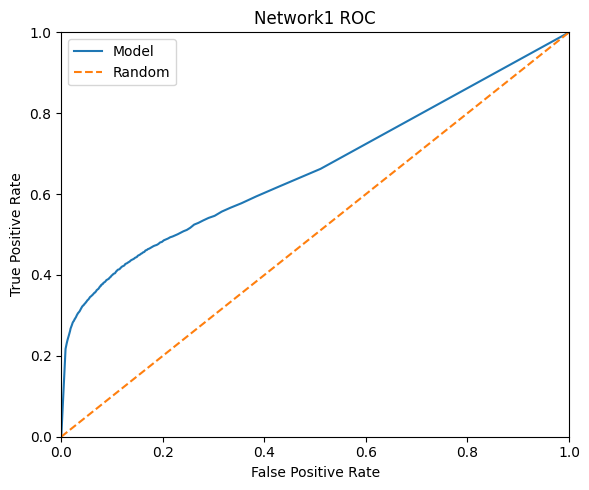

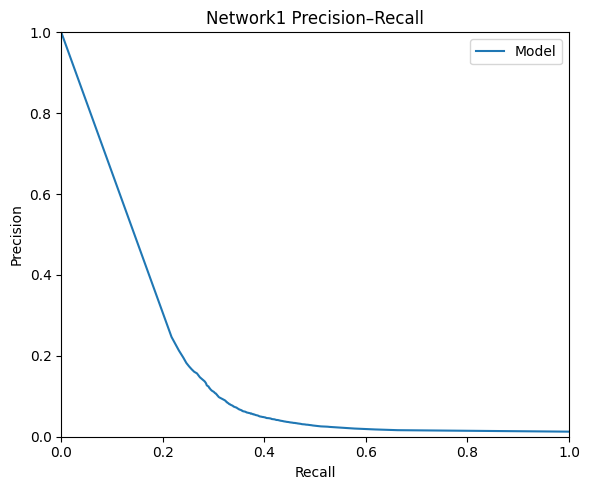

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve, precision_recall_curve,
    roc_auc_score, average_precision_score
)

BENCH_ROOT = Path("/Users/zoeazra/Documents/CLS/Y2/Thesis/Implementation/BurnInjuries/benchmark_data")
RESULTS_DIR = Path("/Users/zoeazra/Documents/CLS/Y2/Thesis/Implementation/BurnInjuries/benchmark_results/piglasso")
OUT_DIR = Path( "/Users/zoeazra/Documents/CLS/Y2/Thesis/Implementation/BurnInjuries/benchmark_results/plotting")
OUT_DIR.mkdir(parents=True, exist_ok=True)

NETWORK_NUM = 1  # change to 2 later
NETWORK_DIR = BENCH_ROOT / f"Network{NETWORK_NUM}"
TF_FILE = NETWORK_DIR / "input data" / f"net{NETWORK_NUM}_transcription_factors.tsv"

GOLD_DIR = NETWORK_DIR / "gold standard"
GOLD_FILE = GOLD_DIR / f"DREAM5_NetworkInference_GoldStandard_Network{NETWORK_NUM}.tsv"

# Choose how to convert piglasso > edge score:
# "max" : max edge stability across lambdas (simple & common)
# "mean": mean stability across lambdas
PIG_SCORE_MODE = "max"


def load_tf_list(tf_path: Path) -> set[str]:
    if not tf_path.exists():
        raise FileNotFoundError(f"TF file not found: {tf_path}")
    # typically 1 column of TF names; tolerate header/no header
    df = pd.read_csv(tf_path, sep="\t", header=None)
    tfs = set(df.iloc[:, 0].astype(str).str.strip().tolist())
    tfs = {t for t in tfs if t and t.lower() not in {"nan", "none"}}
    return tfs

def find_gold_file(root: Path, pattern: str) -> Path:
    hits = sorted(root.glob(pattern))
    if not hits:
        raise FileNotFoundError(f"No gold standard matched pattern: {pattern}\nUnder: {root}")
    if len(hits) > 1:
        print("[WARN] Multiple gold standards found; using first:")
        for h in hits[:10]:
            print("  -", h)
    return hits[0]

def load_gold_directed_edges(gold_path: Path) -> set[tuple[str, str]]:
    df = pd.read_csv(gold_path, sep="\t")

    if df.shape[1] < 3:
        raise ValueError("Expected at least 3 columns (TF, target, label).")

    regs = df.iloc[:, 0].astype(str).str.strip()
    tars = df.iloc[:, 1].astype(str).str.strip()

    # robust label parsing (handles 1, "1", 1.0, etc.)
    labels = pd.to_numeric(df.iloc[:, 2], errors="coerce").fillna(0).astype(int)

    edges = {
        (r, t)
        for r, t, lab in zip(regs, tars, labels)
        if lab == 1 and r and t and r != t
    }
    return edges

def load_piglasso_pkl(pkl_path: Path) -> dict:
    with open(pkl_path, "rb") as f:
        return pickle.load(f)

def piglasso_scores_from_payload(payload: dict, mode: str = "max") -> tuple[list[str], np.ndarray]:
    """
    payload["edge_counts_all"] shape: (p, p, lamlen)
    payload["success_counts"] shape: (lamlen,)
    Score edges by stability across subsamples and lambdas.
    """
    E = np.array(payload["edge_counts_all"], dtype=float)      # (p,p,L)
    succ = np.array(payload["success_counts"], dtype=float)    # (L,)
    genes = list(map(str, payload["genes"]))

    # avoid divide by zero
    succ = np.where(succ <= 0, np.nan, succ)

    # stability per lambda: proportion of successes
    S = E / succ.reshape(1, 1, -1)  # (p,p,L)

    if mode == "max":
        score_mat = np.nanmax(S, axis=2)
    elif mode == "mean":
        score_mat = np.nanmean(S, axis=2)
    else:
        raise ValueError("mode must be 'max' or 'mean'")

    # zero diagonal
    np.fill_diagonal(score_mat, 0.0)

    return genes, score_mat

def build_undirected_pred_scores(genes: list[str], score_mat: np.ndarray) -> dict[tuple[str, str], float]:
    """
    Convert gene x gene score matrix to undirected edge scores:
      score({i,j}) = max(score(i,j), score(j,i))
    """
    idx = {g: i for i, g in enumerate(genes)}
    pred = {}

    p = len(genes)
    for i in range(p):
        for j in range(i+1, p):
            g1, g2 = genes[i], genes[j]
            s = float(max(score_mat[i, j], score_mat[j, i]))
            pred[(g1, g2)] = s
    return pred

def build_directed_tf_scores(genes: list[str], score_mat: np.ndarray, tfs: set[str]) -> dict[tuple[str, str], float]:
    """
    Returns scores for directed edges (tf -> gene) for tf in TF list.
    score(tf->g) = score_mat[tf_index, g_index]
    """
    idx = {g: i for i, g in enumerate(genes)}
    pred = {}

    # Only TFs present in gene list
    tfs_in = [tf for tf in tfs if tf in idx]

    for tf in tfs_in:
        i = idx[tf]
        for g in genes:
            if g == tf:
                continue
            j = idx[g]
            pred[(tf, g)] = float(score_mat[i, j])
    return pred

def evaluate_directed_tf_universe(
    pred_scores: dict[tuple[str, str], float],
    gold_directed: set[tuple[str, str]],
    tfs: set[str],
    genes: list[str],
):
    """
    Universe = all directed pairs (tf -> g) where tf in TFs, g in genes, tf != g
    Positive if (tf,g) in gold_directed else 0.
    Score = pred_scores[(tf,g)] (should exist) else 0.
    """
    y_true = []
    y_score = []

    genes_set = set(genes)
    tfs_in = [tf for tf in sorted(tfs) if tf in genes_set]

    n_candidates = 0
    n_pos = 0

    for tf in tfs_in:
        for g in genes:
            if g == tf:
                continue
            n_candidates += 1
            label = 1 if (tf, g) in gold_directed else 0
            n_pos += label
            y_true.append(label)
            y_score.append(pred_scores.get((tf, g), 0.0))

    y_true = np.array(y_true, dtype=int)
    y_score = np.array(y_score, dtype=float)

    if y_true.sum() == 0:
        raise RuntimeError("No positives found in evaluation universe (check TF list vs gold standard naming).")

    auroc = roc_auc_score(y_true, y_score)
    aupr = average_precision_score(y_true, y_score)

    # random baselines
    auroc_rand = 0.5
    aupr_rand = float(n_pos / n_candidates)  # prevalence baseline for PR

    genes_set = set(genes)
    tfs_in = [tf for tf in tfs if tf in genes_set]
    print(f"[INFO] TF overlap with piglasso genes: {len(tfs_in)}/{len(tfs)}")
    print(f"[INFO] Piglasso genes: {len(genes)}")
    print(f"[INFO] Gold directed edges (positives): {len(gold_dir)}")

    print("Score min:", y_score.min())
    print("Score max:", y_score.max())
    print("Unique scores:", len(np.unique(y_score)))

    return {
        "y_true": y_true,
        "y_score": y_score,
        "auroc": float(auroc),
        "aupr": float(aupr),
        "auroc_random": float(auroc_rand),
        "aupr_random": float(aupr_rand),
        "n_candidates": int(n_candidates),
        "n_pos": int(n_pos),
    }

def plot_roc_pr(y_true: np.ndarray, y_score: np.ndarray, title_prefix: str = ""):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    prec, rec, _ = precision_recall_curve(y_true, y_score)

    # ROC
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label="Model")
    plt.plot([0,1],[0,1], linestyle="--", label="Random")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title_prefix} ROC")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # PR
    plt.figure(figsize=(6,5))
    plt.plot(rec, prec, label="Model")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title_prefix} Precision–Recall")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ----------------------------
# RUN: Network 1
# ----------------------------
tfs = load_tf_list(TF_FILE)
print(f"[INFO] TFs loaded: {len(tfs)} from {TF_FILE.name}")

gold_path = GOLD_FILE
gold_dir = load_gold_directed_edges(gold_path)
# gold_und = to_undirected_set(gold_dir)
print(f"[INFO] Gold standard directed edges: {len(gold_dir)}")
# print(f"[INFO] Gold standard undirected edges: {len(gold_und)}")
print(f"[INFO] Gold file used: {gold_path}")

# Pick one piglasso result pkl to evaluate (you can loop later)
pkl_files = sorted(RESULTS_DIR.glob("*.pkl"))
if not pkl_files:
    raise FileNotFoundError(f"No .pkl piglasso results found in {RESULTS_DIR}")

pkl_path = pkl_files[0]
print(f"[INFO] Using piglasso result: {pkl_path.name}")

payload = load_piglasso_pkl(pkl_path)
genes, score_mat = piglasso_scores_from_payload(payload, mode=PIG_SCORE_MODE)
pred_scores = build_directed_tf_scores(genes, score_mat, tfs)

all_genes = set(genes)
res = evaluate_directed_tf_universe(
    pred_scores=pred_scores,
    gold_directed=gold_dir,
    tfs=tfs,
    genes=genes,
)
print("Example piglasso genes:", list(all_genes)[:10])
# print("Example gold genes:", list(next(iter(gold_und))))

print("\n===== RESULTS =====")
print("AUROC:", res["auroc"], " (random:", res["auroc_random"], ")")
print("AUPR :", res["aupr"],  " (random prevalence:", res["aupr_random"], ")")
print("Candidates:", res["n_candidates"], " Positives:", res["n_pos"])
print("===================\n")


plot_roc_pr(res["y_true"], res["y_score"], title_prefix=f"Network1")






The accuracy results for this benchmarking method seems to be not that great. This could have to do with the fact that the data used as gold standard has directional TF > gene relationships instead of undirected gene-gene interaction, which is what graphical lasso assumes.